[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YangKCLab/social-media-analysis/blob/main/docs/topics/stats/correlation-analysis.ipynb)

# Correlation analysis

Two values are correlated when a change in one value goes with a change in the other value.
This notebook plots the number of friends against the number of followers for 698 Twitter accounts, tests the correlation with the Spearman and the Pearson coefficient, and draws a 2D histogram.

Sections: Load the Botwiki-2019 data, Scatter plot, Log axes, Spearman and Pearson, 2D histogram, Log color scale.

Packages beyond the standard library: `numpy`, `pandas`, `matplotlib`, `scipy`.
Install them with `uv add numpy pandas matplotlib scipy` (or `pip install`).
Colab already has all four.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats

# Figure settings: a larger font, and tick marks drawn behind the data.
plt.rcParams.update({"font.size": 14, "axes.axisbelow": True})

## Load the Botwiki-2019 data

The data is Botwiki-2019: 698 Twitter accounts that identified themselves as bots, from the
[Bot Repository](https://botometer.osome.iu.edu/bot-repository/datasets.html)
([Yang et al., 2020](https://doi.org/10.1609/aaai.v34i01.5460)). The dataset has the license
[CC BY-NC-ND 4.0](https://creativecommons.org/licenses/by-nc-nd/4.0/). This notebook uses two
numbers for each account: the number of followers and the number of friends.

In [2]:
import gzip
import json
import pathlib
import urllib.request

import pandas as pd

# The file is not in the site repository. This cell downloads it once from the
# public course repository, at a fixed commit.
url = (
    "https://raw.githubusercontent.com/YangKCLab/social-media-ds-course/"
    "b4a210426ebfec34f2e983983efde03eeb3dba8d/demos/stats/botwiki-2019_tweets.json.gz"
)
path = pathlib.Path("data") / "botwiki-2019_tweets.json.gz"
path.parent.mkdir(exist_ok=True)
if not path.exists():
    urllib.request.urlretrieve(url, path)

with gzip.open(path) as f:
    botwiki = json.load(f)
botwiki_df = pd.DataFrame.from_records([item["user"] for item in botwiki])
botwiki_df = botwiki_df[["followers_count", "friends_count"]]
len(botwiki_df)    # 698

698

The cell downloads the file (154 KB) into `data/` next to this notebook, unless the file is already there.
The table has 698 rows, one for each account.
The source file has 42 fields for each account, and the cell keeps two of them: `followers_count` and `friends_count`.
Friends are the accounts that an account follows.

In [3]:
botwiki_df.median()

followers_count    81.0
friends_count       1.0
dtype: float64

The median account has 81 followers and 1 friend.

## Scatter plot

Is there a correlation between the number of friends and the number of followers?
Look at the data first.
In a scatter plot, each point is one account.

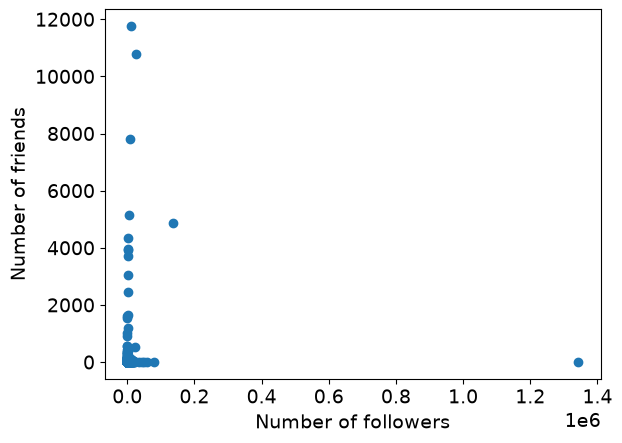

In [4]:
plt.scatter(botwiki_df.followers_count, botwiki_df.friends_count)
plt.xlabel("Number of followers")
plt.ylabel("Number of friends")
plt.show()

Both values are highly skewed, so almost all points are in the lower left corner.

## Log axes

Use the log scale for both the x-axis and the y-axis.

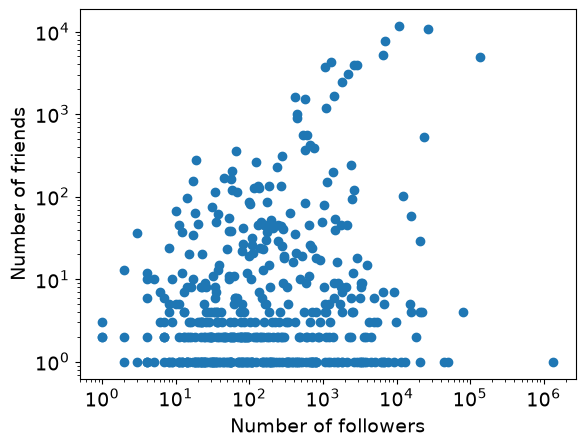

In [5]:
plt.scatter(botwiki_df.followers_count, botwiki_df.friends_count)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of followers")
plt.ylabel("Number of friends")
plt.show()

The points are now spread over the plot.
A log axis cannot show 0, so the accounts with 0 friends are not in the plot.
The next cell counts them.

In [6]:
(botwiki_df.friends_count == 0).sum()

np.int64(207)

207 of the 698 accounts have 0 friends.

## Spearman and Pearson

A correlation coefficient is a value between -1 and 1.
A positive value means that the two values rise together, and a value near 0 means no correlation.
The test also gives a p-value.
Its null hypothesis is that there is no correlation.

- The Pearson coefficient measures a linear relationship. Extreme values distort it.
- The Spearman coefficient is a rank correlation. It uses the ranks of the values, so it works for skewed data.

Both functions use all 698 accounts, also the accounts with 0 friends.

In [7]:
x, y = botwiki_df.followers_count, botwiki_df.friends_count

scipy.stats.spearmanr(x, y)

SignificanceResult(statistic=np.float64(0.2728021178726365), pvalue=np.float64(2.2341190901787878e-13))

In [8]:
scipy.stats.pearsonr(x, y)

PearsonRResult(statistic=np.float64(0.033102243392325974), pvalue=np.float64(0.3825416242206567))

The Spearman coefficient is 0.273 with a p-value of 2.2e-13.
This is a weak positive correlation, and it is significant.

The Pearson coefficient is 0.033 with a p-value of 0.38.
Pearson finds no correlation.
A few accounts with very high values dominate the result.

For skewed data such as these counts, use the Spearman coefficient.

## 2D histogram

Many points overlap in a scatter plot, so you cannot see where most of them are.
A 2D histogram counts the points in each cell of a grid and shows the counts as colors.

The bins are in log scale on both axes.
`plt.hist2d` returns four values.
The fourth value, `h[3]`, is the image that `plt.colorbar` needs.

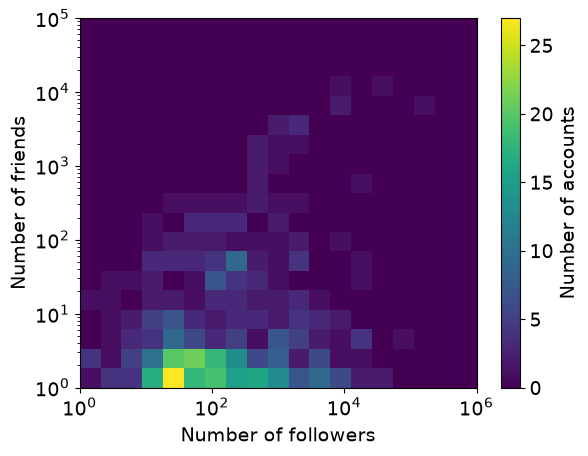

In [9]:
h = plt.hist2d(
    botwiki_df.followers_count,
    botwiki_df.friends_count,
    bins=[np.logspace(0, 6, 20), np.logspace(0, 5, 20)],
)
plt.xscale("log")
plt.yscale("log")
plt.colorbar(h[3], label="Number of accounts")
plt.xlabel("Number of followers")
plt.ylabel("Number of friends")
plt.show()

The brightest cells are in the bottom rows, between 10 and 1,000 followers.
Most of the counted accounts have only a few friends.
The fullest cell holds 27 accounts.

`h[0]` holds the count of each cell.
The next cell adds them up.

In [10]:
h[0].sum()

np.float64(490.0)

The histogram counts 490 of the 698 accounts.
The follower bins go from 1 to 1 million and the friend bins from 1 to 100,000, so an account outside these ranges is not counted.
The accounts with 0 friends are outside.

## Log color scale

When the counts in the cells differ by orders of magnitude, a linear color scale shows only the fullest cells.
The argument `norm="log"` puts the color scale in log scale as well.

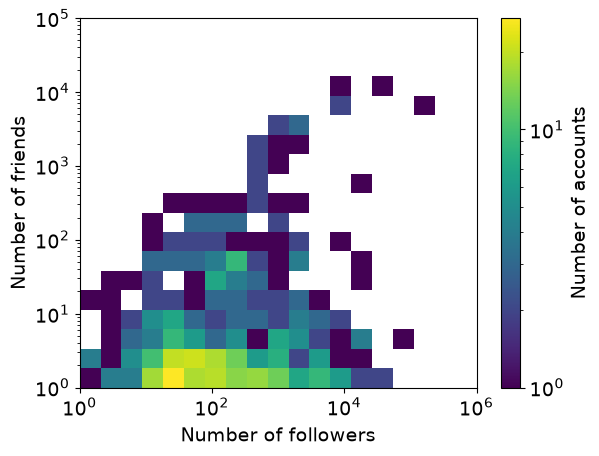

In [11]:
h = plt.hist2d(
    botwiki_df.followers_count,
    botwiki_df.friends_count,
    bins=[np.logspace(0, 6, 20), np.logspace(0, 5, 20)],
    norm="log",
)
plt.xscale("log")
plt.yscale("log")
plt.colorbar(h[3], label="Number of accounts")
plt.xlabel("Number of followers")
plt.ylabel("Number of friends")
plt.show()

A cell with no account is now white, because a log scale cannot show 0.
The cells with one or two accounts are easier to tell apart from the empty cells.

Here the counts go only from 1 to 27.
The log color scale matters more when the counts go from 1 to many thousands.